In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [5]:
# --- Load CSV files ---
files = {
    "GNews_Sindoor": r"/home/atullinux/radhika-repos/College_Research/outputs/gnews_operation_sindoor_headlines.csv",
    "GNews_Pahalgam": r"/home/atullinux/radhika-repos/College_Research/outputs/gnews_pahalgam_attack_headlines.csv",
    "GoogleNews_Sindoor": r"/home/atullinux/radhika-repos/College_Research/outputs/google_news_operation_sindoor_headlines.csv",
    "GoogleNews_Pahalgam": r"/home/atullinux/radhika-repos/College_Research/outputs/google_news_pahalgam_attack_headlines.csv",
    "MediaStack_Sindoor": r"/home/atullinux/radhika-repos/College_Research/outputs/media_stack_operation_sindoor_headlines.csv",
    "MediaStack_Pahalgam": r"/home/atullinux/radhika-repos/College_Research/outputs/media_stack_pahalgam_attack_headlines.csv",
    "NewsAPI_Sindoor": r"/home/atullinux/radhika-repos/College_Research/outputs/news_api_operation_sindoor_headlines.csv",
    "NewsAPI_Pahalgam": r"/home/atullinux/radhika-repos/College_Research/outputs/news_api_pahalgam_attack_headlines.csv",
}


In [6]:
# ✅ Load the DataFrames directly
dfs = {name: pd.read_csv(path) for name, path in files.items()}


In [7]:
# --- BASIC EDA: Shape and nulls ---
for name, df in dfs.items():
    print(f"\n📄 {name} — Shape: {df.shape}")
    print("🔍 Null values:\n", df.isnull().sum())


📄 GNews_Sindoor — Shape: (12, 6)
🔍 Null values:
 source_name     0
author         12
title           0
description     0
url             0
publishedAt     0
dtype: int64

📄 GNews_Pahalgam — Shape: (16, 6)
🔍 Null values:
 source_name     0
author         16
title           0
description     0
url             0
publishedAt     0
dtype: int64

📄 GoogleNews_Sindoor — Shape: (1343, 7)
🔍 Null values:
 source         0
query          0
country        0
date           0
text           0
likes       1343
retweets    1343
dtype: int64

📄 GoogleNews_Pahalgam — Shape: (1600, 7)
🔍 Null values:
 source         0
query          0
country        0
date           0
text           0
likes       1600
retweets    1600
dtype: int64

📄 MediaStack_Sindoor — Shape: (101, 6)
🔍 Null values:
 source_name    0
author         5
title          0
description    1
url            0
publishedAt    0
dtype: int64

📄 MediaStack_Pahalgam — Shape: (44, 6)
🔍 Null values:
 source_name     0
author         40
title          

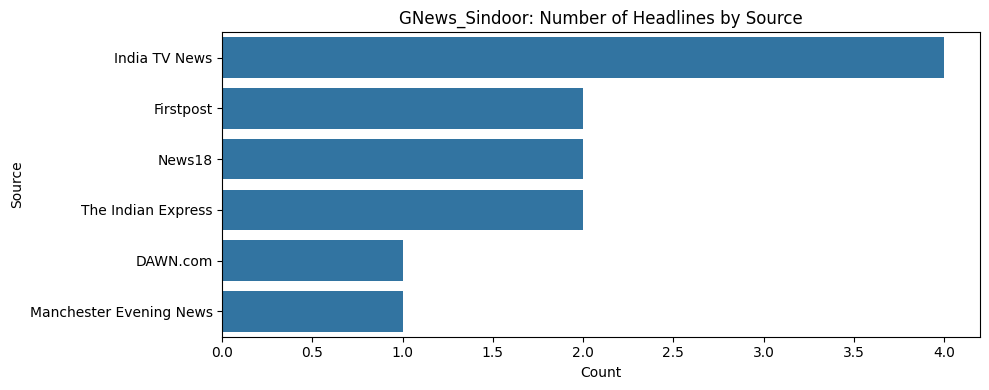

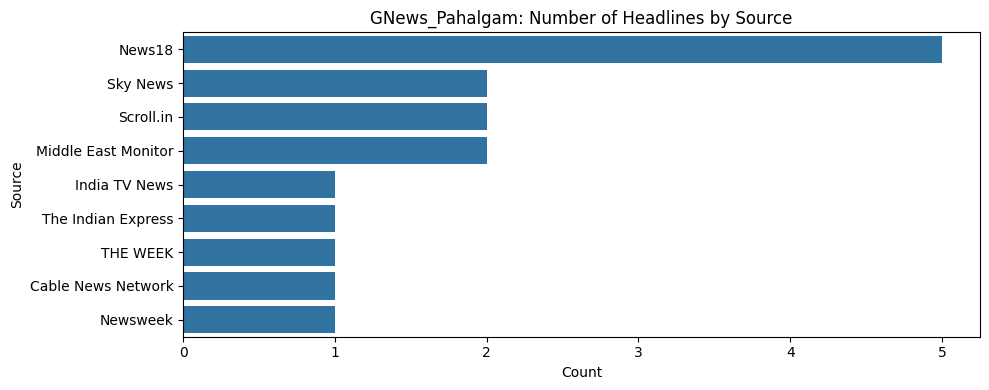

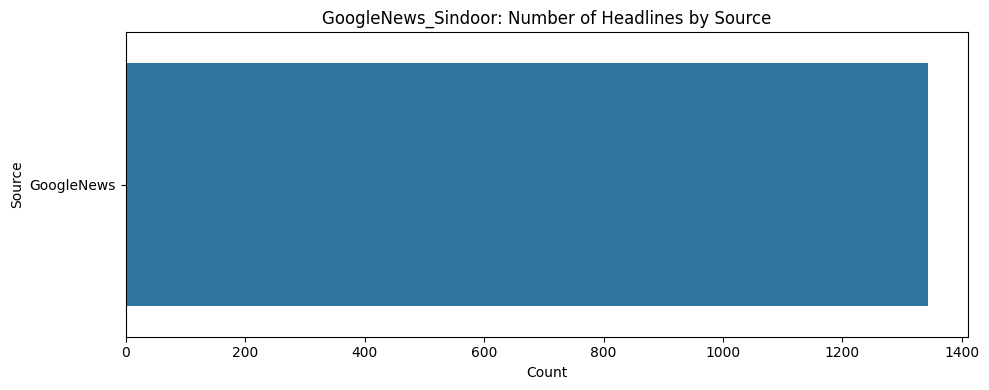

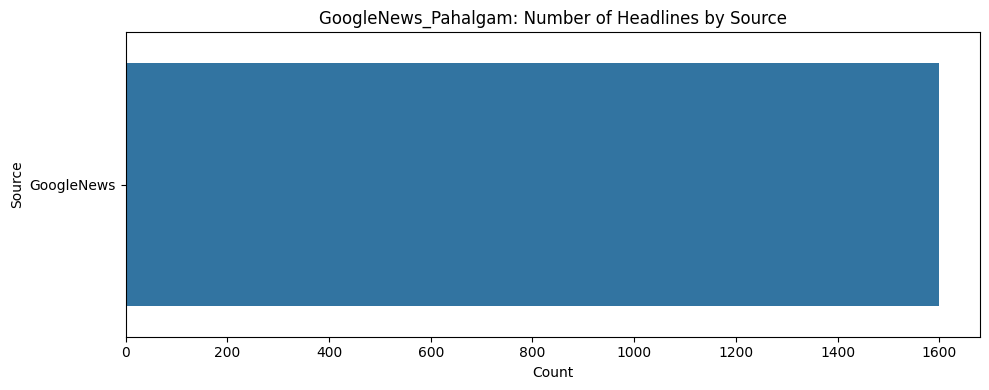

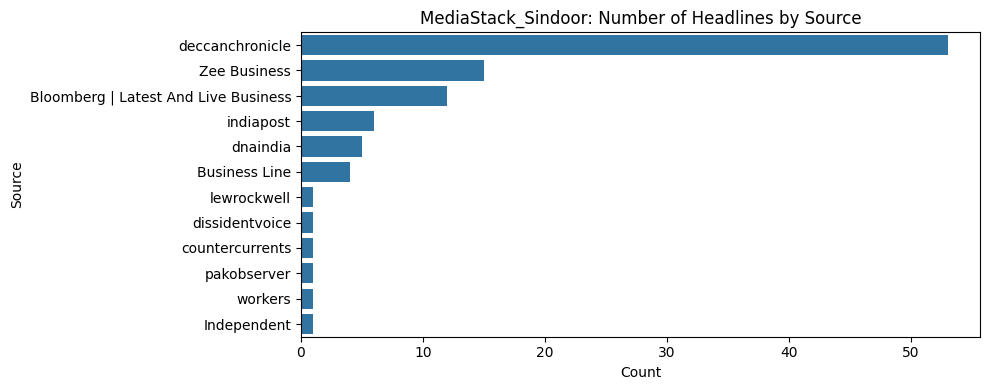

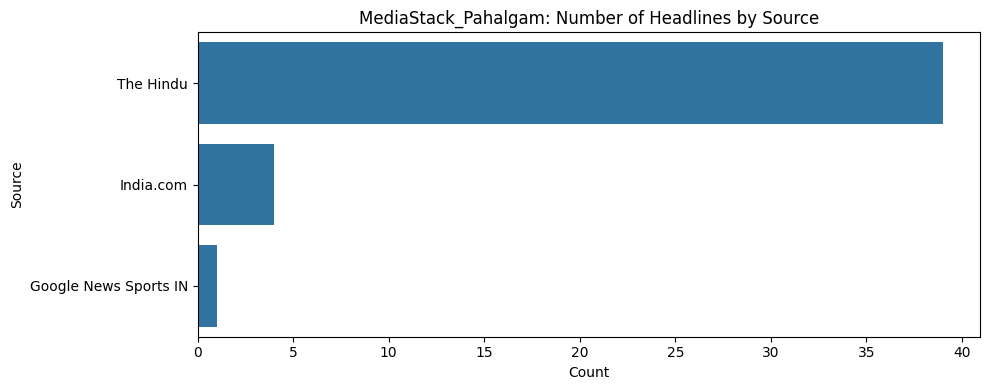

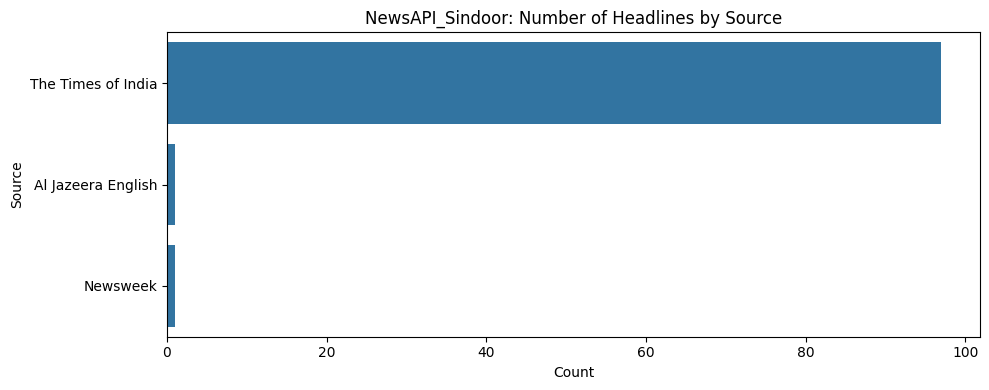

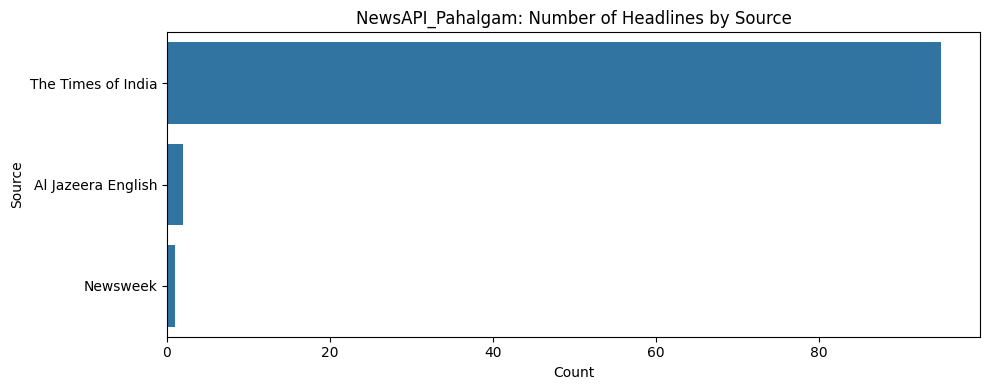

In [8]:
# --- Plot number of headlines per source ---
for name, df in dfs.items():
    plt.figure(figsize=(10, 4))
    source_col = 'source_name' if 'source_name' in df.columns else 'source'
    sns.countplot(y=source_col, data=df, order=df[source_col].value_counts().index)
    plt.title(f"{name}: Number of Headlines by Source")
    plt.xlabel("Count")
    plt.ylabel("Source")
    plt.tight_layout()
    plt.show()

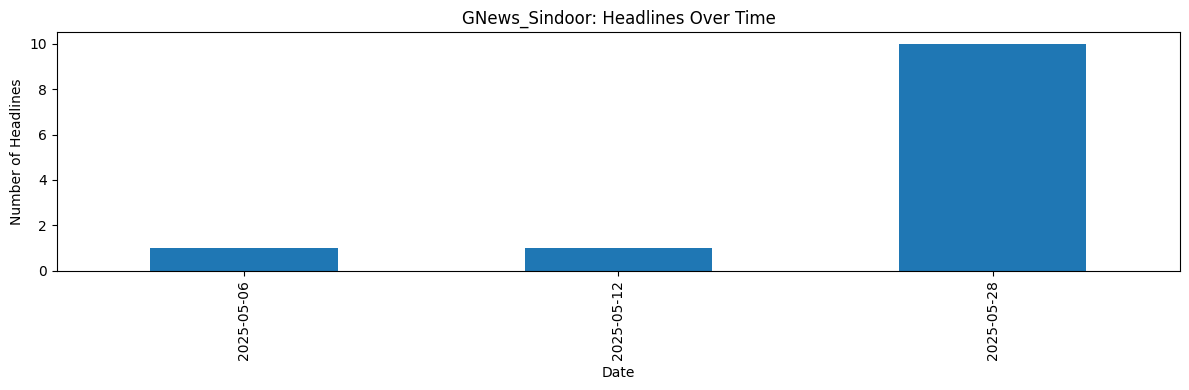

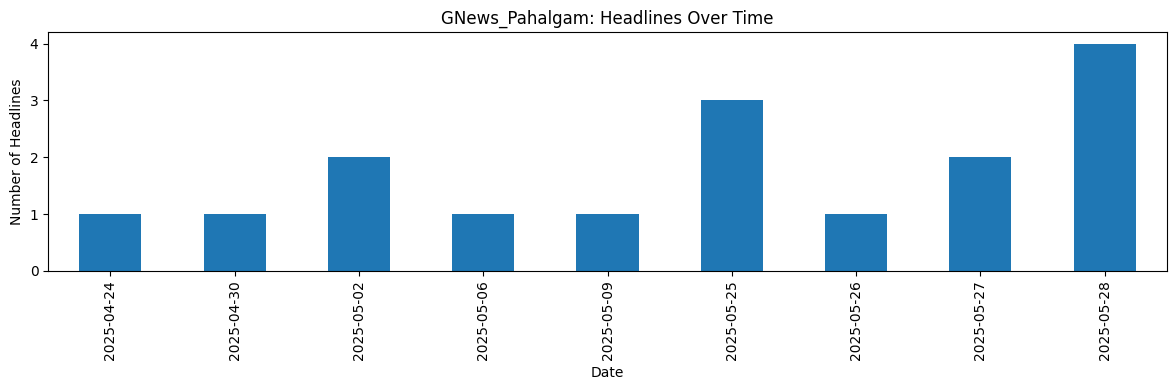

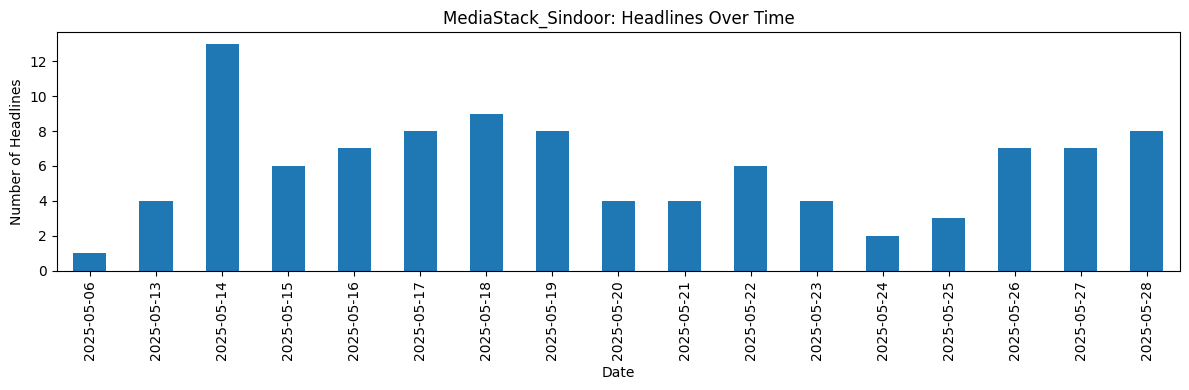

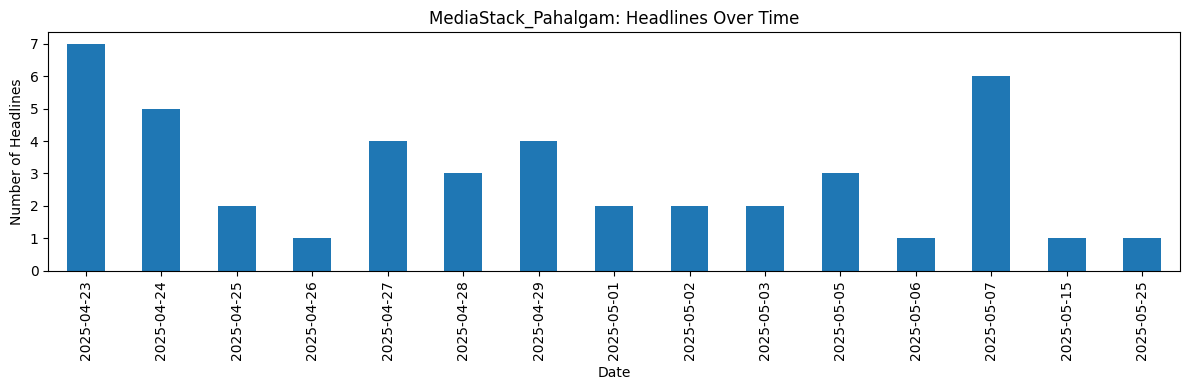

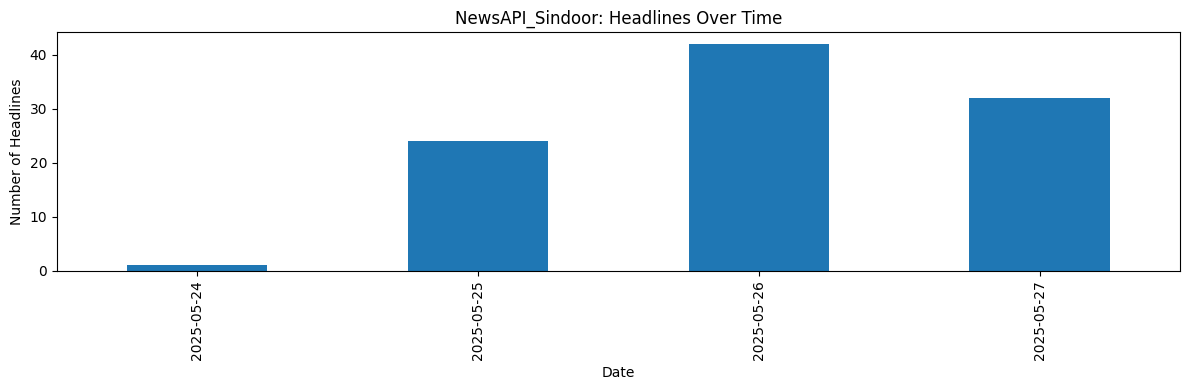

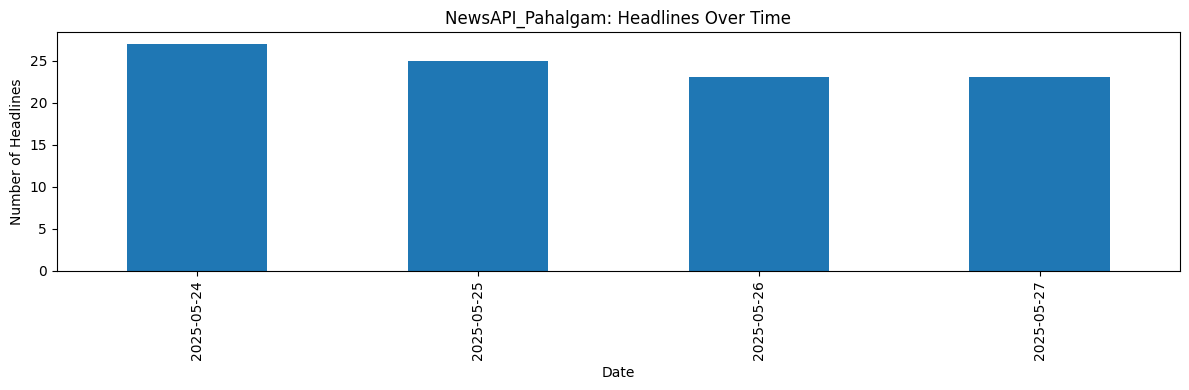

In [9]:

# --- Publish Date Distribution ---
for name, df in dfs.items():
    if 'publishedAt' in df.columns:
        df['publishedAt'] = pd.to_datetime(df['publishedAt'], errors='coerce')
        plt.figure(figsize=(12, 4))
        df['publishedAt'].dt.date.value_counts().sort_index().plot(kind='bar')
        plt.title(f"{name}: Headlines Over Time")
        plt.xlabel("Date")
        plt.ylabel("Number of Headlines")
        plt.tight_layout()
        plt.show()

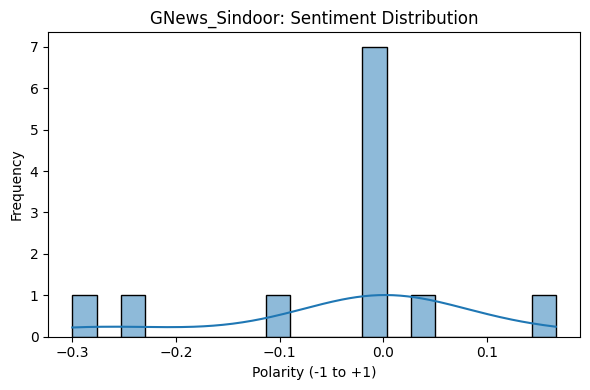

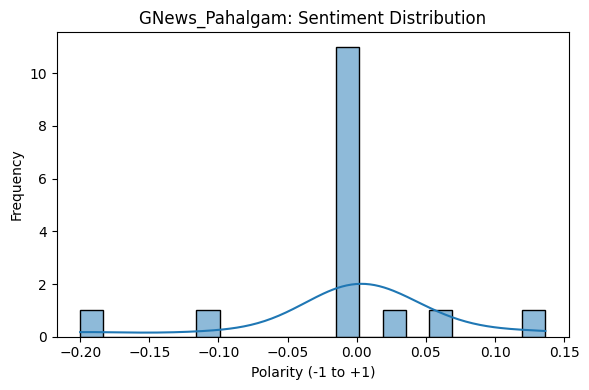

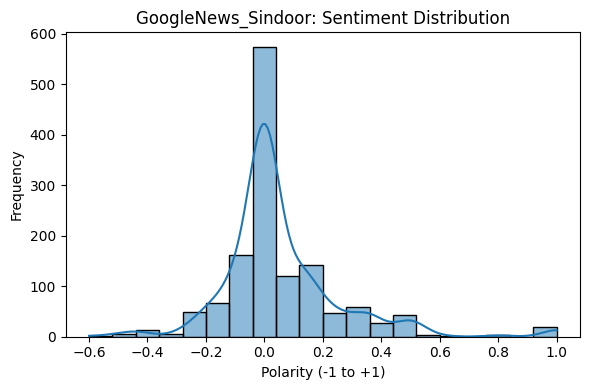

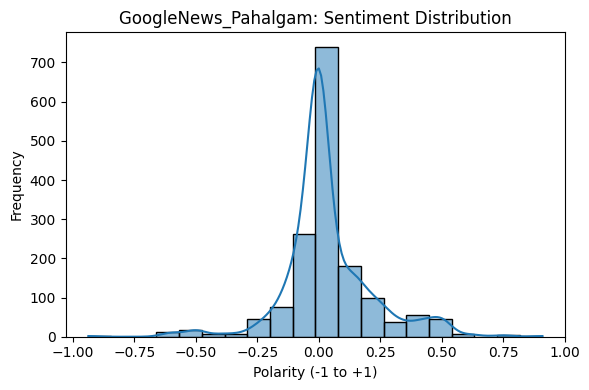

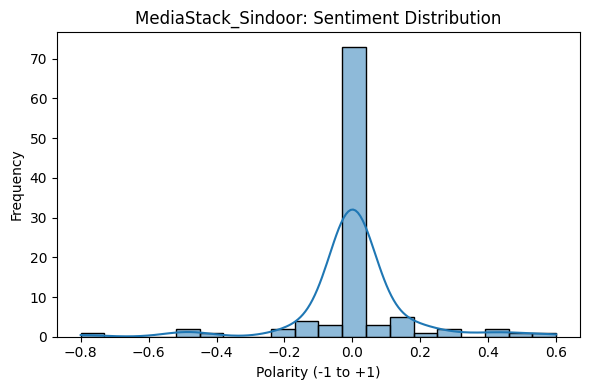

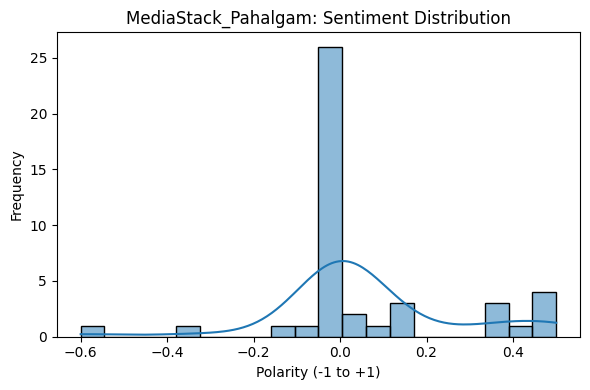

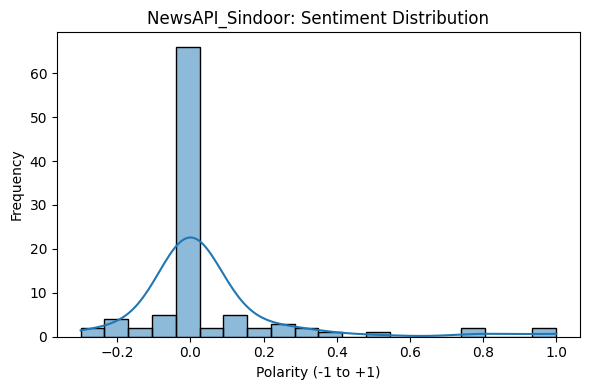

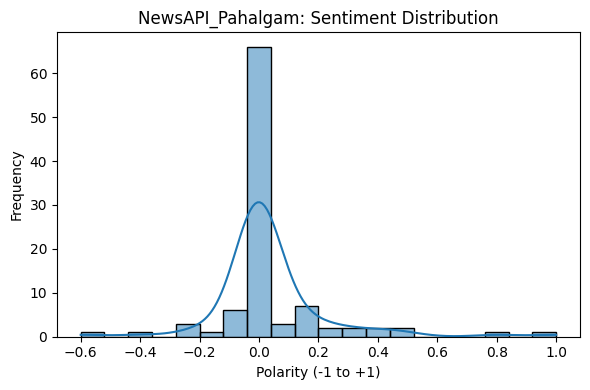

In [10]:
# --- Sentiment Analysis using TextBlob ---
for name, df in dfs.items():
    text_col = 'text' if 'text' in df.columns else 'title'
    df['sentiment'] = df[text_col].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
    plt.figure(figsize=(6, 4))
    sns.histplot(df['sentiment'], bins=20, kde=True)
    plt.title(f"{name}: Sentiment Distribution")
    plt.xlabel("Polarity (-1 to +1)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
